In [ ]:
pip install transformers torch pillow requests

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

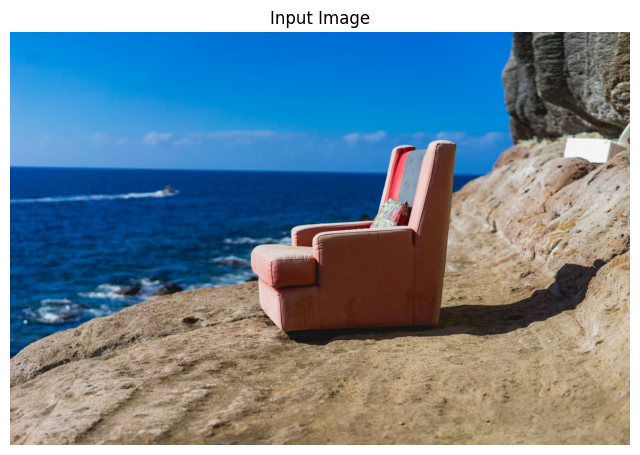

Generated Caption: a toy chair sitting on a rock by the ocean
Question: What is in the picture?
Answer: chair


In [ ]:
from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    BlipForQuestionAnswering
)
from PIL import Image
import requests
import matplotlib.pyplot as plt

# -------------------------------------------------
# Load Image
# -------------------------------------------------

image_url = "https://images.unsplash.com/photo-1519125323398-675f0ddb6308"

raw_image = Image.open(
    requests.get(image_url, stream=True).raw
).convert("RGB")


# -------------------------------------------------
# Image Captioning
# -------------------------------------------------

cap_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

cap_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

inputs = cap_processor(
    raw_image,
    return_tensors="pt"
)

caption_ids = cap_model.generate(
    **inputs,
    max_new_tokens=30
)

caption = cap_processor.decode(
    caption_ids[0],
    skip_special_tokens=True
)


# -------------------------------------------------
# Visual Question Answering
# -------------------------------------------------

vqa_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-vqa-base"
)

vqa_model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base"
)

question = "What is in the picture?"

vqa_inputs = vqa_processor(
    raw_image,
    question,
    return_tensors="pt"
)

answer_ids = vqa_model.generate(
    **vqa_inputs
)

answer = vqa_processor.decode(
    answer_ids[0],
    skip_special_tokens=True
)


# -------------------------------------------------
# Display Image
# -------------------------------------------------

plt.figure(figsize=(8, 6))
plt.imshow(raw_image)
plt.axis("off")
plt.title("Input Image")
plt.show()


# -------------------------------------------------
# Display Results
# -------------------------------------------------

print("Generated Caption:", caption)
print("Question:", question)
print("Answer:", answer)